In [2]:
import numpy as np
import matplotlib.pyplot as plt

from scipy.stats import norm

In [ ]:
# Portfolio Credit Risk Modelling with a multifactor normal copula model.
np.random.seed(4198)

# Model parameters
m = 100              # 100 obligors
d = 10               # 10-factors
k = np.arange(1, m + 1)
pk = 0.01 * (1 + np.sin(16 * np.pi * k / m))
ck = (np.ceil(5 * k / m))**2

# Factor Loadings
a = np.array(
    [[1.0 / np.sqrt(d) * (1 - np.exp(-j/k)) for j in range(1, d+1)] for k in range(1, m+1)])

b = np.sqrt(1 - np.sum(a**2, axis=1))

# Sample Size
N = 10_000
xs_plain = np.linspace(0, 151, 30)
xs_is = np.linspace(0, 201, 40)

In [ ]:
def plain(x, N):
    # Simulates Portfolio losses under the model
    # and estimate the probability of large defaults
    L = np.zeros(N)
    for i in range(N):
        Z = np.random.normal(0, 1, d)
        U = a @ Z + b * np.random.normal(0, 1, m)
        defaults = (U <= norm.ppf(pk)).astype(int)
        L[i] = np.sum(ck * defaults)

    H = L >= x
    prob_large_default = np.mean(H)
    se = np.std(H, ddof=1) / np.sqrt(N)
    re = se / np.abs(prob_large_default + 1e-12)

    return prob_large_default, se, re

# Simulates Portfolio losses under the model
# and estimate the probability of large defaults
plain_p = []
plain_se = []
plain_re = []
for x in xs_plain:
    p, se, re = plain(x, N)
    plain_p.append(p)
    plain_se.append(se)
    plain_re.append(re)

plain_p = np.array(plain_p)
plain_se = np.array(plain_se)
plain_re = np.array(plain_re)

In [ ]:
from utility import bisection_method

def importance_sampling(x, N):
    # shift conditional distribution given Z
    H = np.zeros(N)

    for i in range(N):
        Z = np.random.normal(0, 1, d)
        p_kZ = norm.cdf((norm.ppf(pk) - a @ Z) / b)
        expLz = np.sum(ck * p_kZ)
        thetaZ = 0.0
        if expLz < x:
            fn = lambda th: np.sum( (ck * p_kZ) / (p_kZ + np.exp(-th * ck) * (1.0 - p_kZ)) ) - x
            thetaZ = bisection_method(fn, 0.0, 20.0, eps=1e-6)
        
        pk_thetaZ = p_kZ * np.exp(thetaZ * ck) / (1.0 + p_kZ * (np.exp(thetaZ * ck) - 1))
        defaults = (np.random.uniform(0, 1, m) <= pk_thetaZ).astype(int)
        L = np.sum(ck * defaults)
        H[i] = (L >= x) * np.exp(-thetaZ * L + np.sum(np.log(1 + p_kZ * (np.exp(thetaZ * ck) - 1))))
        
    
    prob_large_default = np.mean(H)
    se = np.std(H, ddof=1) / np.sqrt(N)
    re = se / np.abs(prob_large_default + 1e-12)
    return prob_large_default, se, re


# Simulates Portfolio losses under the model
# and estimate the probability of large defaults
is_p = []
is_se = []
is_re = []
for x in xs_is:
    p, se, re = importance_sampling(x, N)
    is_p.append(p)
    is_se.append(se)
    is_re.append(re)
    

is_p = np.array(is_p)
is_se = np.array(is_se)
is_re = np.array(is_re)

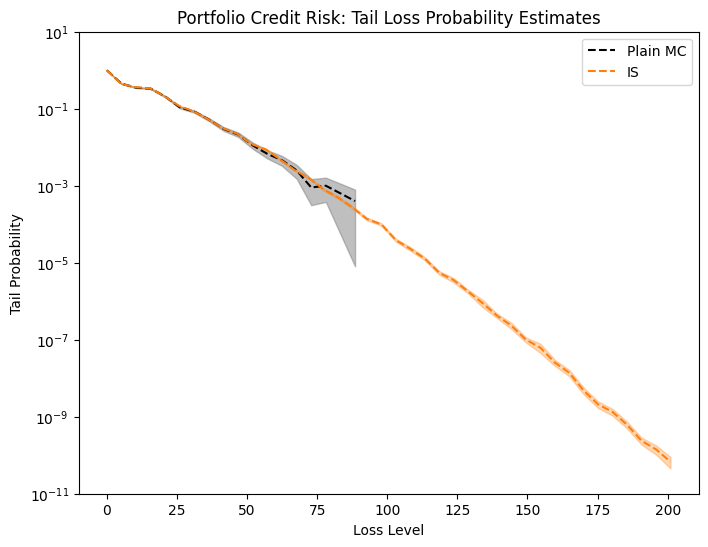

In [61]:
# Plot tail probability against loss level
# 95% confidence intervals
mask = (plain_p > 0) & (plain_re < 0.7)

plt.figure(figsize=(8, 6))

plt.plot(xs_plain[mask], plain_p[mask], label='Plain MC', color='black', linestyle='--')
plt.fill_between(xs_plain[mask],
                 plain_p[mask] - 1.96 * plain_se[mask],
                 plain_p[mask] + 1.96 * plain_se[mask],
                 color='gray', alpha=0.5)

plt.plot(xs_is, is_p, label='IS', color='tab:orange', linestyle='--')
plt.fill_between(xs_is,
                 is_p - 1.96 * is_se,
                 is_p + 1.96 * is_se,
                 color='tab:orange', alpha=0.3)

plt.yscale('log')
plt.ylim(1e-11, 1e1)

plt.xlabel('Loss Level')
plt.ylabel('Tail Probability')

plt.legend()

plt.title('Portfolio Credit Risk: Tail Loss Probability Estimates')

plt.savefig('../report/assets/portfolio-credit-risk-plain-is.png')